In [3]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
df = pd.read_csv('/content/customer_support_tickets.csv')

print(df.head())
print(df.columns)

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [6]:
df.rename(columns={
    'Ticket Description': 'ticket_text',
    'Category': 'category',
    'Priority': 'priority'
}, inplace=True)

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['ticket_text'].apply(clean_text)

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

In [9]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'ticket_text', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'clean_text'],
      dtype='object')


In [10]:
y_category = df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

In [11]:
model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model_category.predict(X_test)

print("Category Accuracy:", accuracy_score(y_test, y_pred))
print("\nCategory Classification Report:\n")
print(classification_report(y_test, y_pred))

Category Accuracy: 0.19716646989374262

Category Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.10      0.12       357
Cancellation request       0.20      0.21      0.21       327
     Product inquiry       0.17      0.17      0.17       316
      Refund request       0.21      0.26      0.23       345
     Technical issue       0.22      0.25      0.23       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



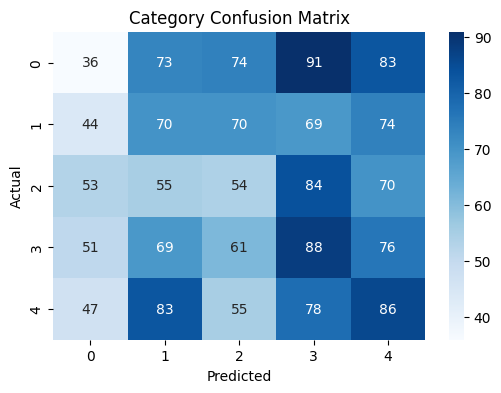

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
y_priority = df['Ticket Priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

In [15]:
model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train_p, y_train_p)

LogisticRegression(max_iter=1000)

In [16]:
y_pred_p = model_priority.predict(X_test_p)

print("Priority Accuracy:", accuracy_score(y_test_p, y_pred_p))
print("\nPriority Classification Report:\n")
print(classification_report(y_test_p, y_pred_p))

Priority Accuracy: 0.256198347107438

Priority Classification Report:

              precision    recall  f1-score   support

    Critical       0.23      0.24      0.24       411
        High       0.27      0.29      0.28       409
         Low       0.24      0.23      0.24       415
      Medium       0.29      0.26      0.27       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



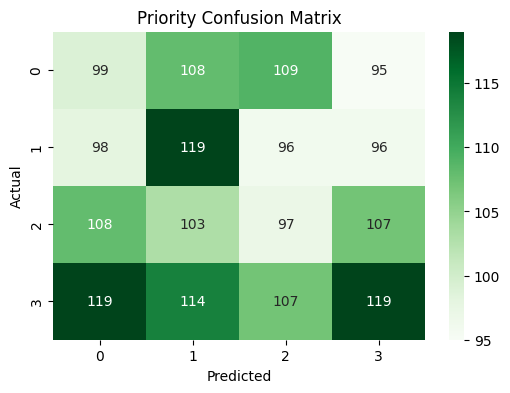

In [17]:
cm_p = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(6,4))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Greens')
plt.title("Priority Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])

    category_pred = model_category.predict(vector)[0]
    priority_pred = model_priority.predict(vector)[0]

    print("Predicted Category:", category_pred)
    print("Predicted Priority:", priority_pred)

# Example
predict_ticket("My account is locked and I cannot login urgently.")

Predicted Category: Billing inquiry
Predicted Priority: High
